# Module 03B - Training

This notebook turns training knobs into visible behavior. You will compare learning rates, implement AdamW, inspect gradient clipping, plot a warmup/cosine schedule, and practice reading train/validation curves.

Run this after finishing Module 03's `SGD`, layers, and losses. The AdamW, clipping, and schedule cells are expected to fail until you implement the corresponding TODOs in `g2c/`.

1. Read the lesson page (`docs/modules/03b-training.md`).
2. Open this notebook with `.venv/bin/python scripts/open_notebook.py 03b`.
3. Answer the `Question:` / `Answer:` cells below.
4. When you're ready, ask a coding agent to grade your notebook.

Partial work is fine. Blank `Answer: ""` strings are skipped, not counted wrong. If you'd like a hint instead of a grade, write the request inline in the answer string and the agent will tutor first.

In [1]:
from __future__ import annotations

import math
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch

repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / "pyproject.toml").exists():
    repo_root = repo_root.parent

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from g2c.nn import CrossEntropyLoss, Linear, ReLU, SGD, Sequential
from g2c.training import AdamW, clip_grad_norm_, cosine_with_warmup
from g2c.notebook_extras.training import plot_optimizer_decision_snapshots

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True

## Exercise 1 - Learning-rate sweep

The same model can crawl, learn, or explode depending on the learning rate. Keep the data, model shape, seed, and step budget fixed; vary only `lr`.

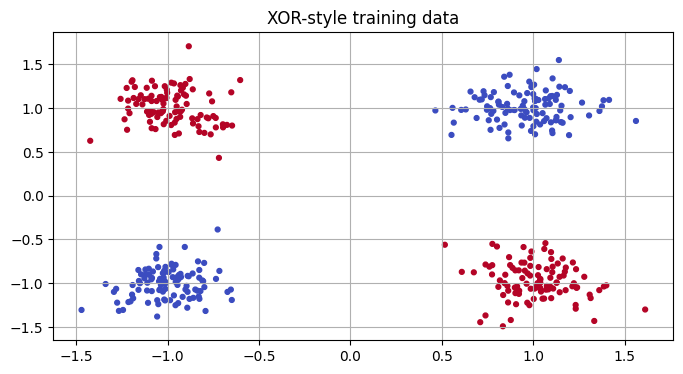

In [2]:
def make_xor_data(n_per_corner: int = 128, noise: float = 0.18):
    torch.manual_seed(0)
    centers = torch.tensor([
        [-1.0, -1.0],
        [-1.0, 1.0],
        [1.0, -1.0],
        [1.0, 1.0],
    ])
    labels = torch.tensor([0, 1, 1, 0])
    x = centers.repeat_interleave(n_per_corner, dim=0)
    y = labels.repeat_interleave(n_per_corner)
    x = x + noise * torch.randn_like(x)
    order = torch.randperm(len(x))
    return x[order], y[order]


x_all, y_all = make_xor_data()
split = int(0.8 * len(x_all))
x_train, y_train = x_all[:split], y_all[:split]
x_val, y_val = x_all[split:], y_all[split:]

plt.scatter(x_train[:, 0], x_train[:, 1], c=y_train, s=12, cmap="coolwarm")
plt.title("XOR-style training data")
plt.show()

In [3]:
def build_mlp(hidden: int = 32) -> Sequential:
    return Sequential(
        Linear(2, hidden),
        ReLU(),
        Linear(hidden, 2),
    )


def accuracy(model: Sequential, x: torch.Tensor, y: torch.Tensor) -> float:
    with torch.no_grad():
        preds = model(x).argmax(dim=-1)
        return float((preds == y).float().mean().item())


def train_classifier(
    *,
    optimizer_cls,
    lr: float,
    steps: int = 300,
    weight_decay: float = 0.0,
    seed: int = 0,
):
    torch.manual_seed(seed)
    model = build_mlp()
    loss_fn = CrossEntropyLoss()
    optimizer = optimizer_cls(model.parameters(), lr=lr, weight_decay=weight_decay)
    train_losses = []
    val_losses = []

    for _ in range(steps):
        optimizer.zero_grad()
        train_loss = loss_fn(model(x_train), y_train)
        train_loss.backward()
        optimizer.step()

        if not torch.isfinite(train_loss):
            train_losses.append(float("nan"))
            val_losses.append(float("nan"))
            break

        train_losses.append(float(train_loss.item()))
        with torch.no_grad():
            val_losses.append(float(loss_fn(model(x_val), y_val).item()))

    return model, train_losses, val_losses

lr=0.0001 final_train=0.6791 final_val=0.6798 val_acc=0.718
lr=0.001 final_train=0.6020 final_val=0.6040 val_acc=0.942
lr=0.01 final_train=0.2230 final_val=0.2342 val_acc=1.000
lr=0.1 final_train=0.0118 final_val=0.0157 val_acc=1.000
lr=1 final_train=0.0008 final_val=0.0015 val_acc=1.000


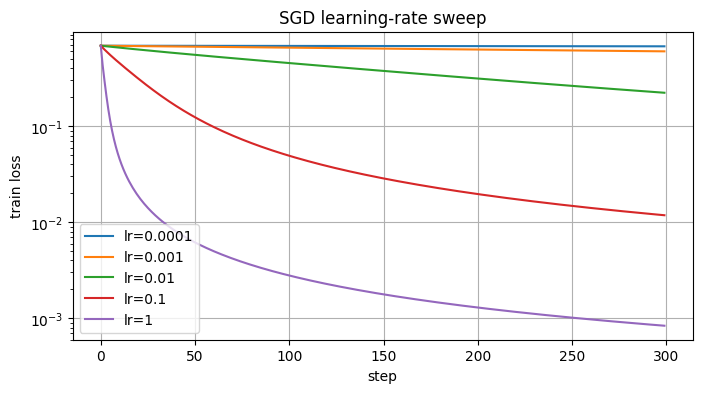

In [4]:
learning_rates = [1e-4, 1e-3, 1e-2, 1e-1, 1.0]
sgd_runs = {}

for lr in learning_rates:
    model, train_losses, val_losses = train_classifier(optimizer_cls=SGD, lr=lr)
    sgd_runs[lr] = (model, train_losses, val_losses)
    print(f"lr={lr:g} final_train={train_losses[-1]:.4f} final_val={val_losses[-1]:.4f} val_acc={accuracy(model, x_val, y_val):.3f}")

for lr, (_, train_losses, _) in sgd_runs.items():
    plt.plot(train_losses, label=f"lr={lr:g}")
plt.yscale("log")
plt.xlabel("step")
plt.ylabel("train loss")
plt.title("SGD learning-rate sweep")
plt.legend()
plt.show()

In [5]:
'Question: Which learning rates crawled, which learned, and which were unstable?'
'Answer: '
'Question: Why is changing only one knob at a time important in this sweep?'
'Answer: '

'Answer: '

## Exercise 2 - AdamW by hand

Before implementing AdamW, compute the first scalar update by hand. This is the whole algorithm in miniature.

In [6]:
p = 1.0
grad = 0.1
lr = 0.001
beta1 = 0.9
beta2 = 0.999
eps = 1e-8

# TODO: compute m, v, m_hat, v_hat, update, and new_p by hand.
m = None
v = None
m_hat = None
v_hat = None
update = None
new_p = None

print("m:", m)
print("v:", v)
print("m_hat:", m_hat)
print("v_hat:", v_hat)
print("update:", update)
print("new_p:", new_p)

m: None
v: None
m_hat: None
v_hat: None
update: None
new_p: None


In [7]:
'Question: Why does bias correction make the first update roughly lr instead of much smaller?'
'Answer: '
'Question: What does AdamW adapt per parameter that SGD does not?'
'Answer: '

'Answer: '

## Exercise 3 - Implement AdamW

Implement `AdamW.step` in `g2c/training/optim.py`, then run the focused tests. The tests are intended to be your implementation checklist.

In [8]:
result = subprocess.run(
    [sys.executable, "-m", "pytest", "tests/test_training.py", "-k", "adamw", "-q"],
    cwd=repo_root,
    text=True,
    capture_output=True,
)
print(result.stdout)
if result.stderr:
    print(result.stderr)
assert result.returncode == 0, "AdamW tests are not passing yet."
print("AdamW tests passed.")

.......                                                                  [100%]

AdamW tests passed.


## Exercise 4 - SGD vs AdamW

Now train the same model with the same data and compare optimizers. The nominal LR ranges are different: AdamW usually uses smaller values than SGD.

The snapshots below connect those curves to the actual classification geometry.


SGD lr=0.1 final val loss 0.0157 val acc 1.000
AdamW lr=0.003 final val loss 0.0065 val acc 1.000
AdamW lr=0.001 final val loss 0.0553 val acc 1.000


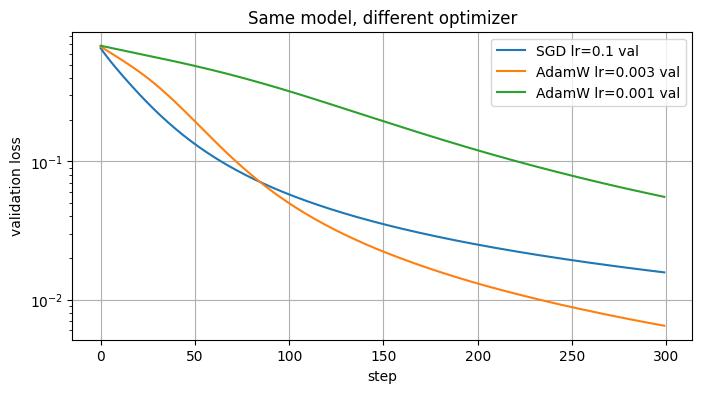

In [9]:
optimizer_runs = {
    "SGD lr=0.1": (SGD, 0.1, 0.0),
    "AdamW lr=0.003": (AdamW, 0.003, 0.01),
    "AdamW lr=0.001": (AdamW, 0.001, 0.01),
}

for label, (optimizer_cls, lr, wd) in optimizer_runs.items():
    model, train_losses, val_losses = train_classifier(
        optimizer_cls=optimizer_cls,
        lr=lr,
        weight_decay=wd,
        steps=300,
        seed=0,
    )
    plt.plot(val_losses, label=f"{label} val")
    print(label, "final val loss", f"{val_losses[-1]:.4f}", "val acc", f"{accuracy(model, x_val, y_val):.3f}")

plt.yscale("log")
plt.xlabel("step")
plt.ylabel("validation loss")
plt.title("Same model, different optimizer")
plt.legend()
plt.show()

### Visualize optimizer trajectories on the data

The loss curve tells you whether a run is improving; the panels below show what that improvement means on the ground. Rows are snapshots after 50, 150, and 300 steps; columns are optimizer settings. The shaded regions are model classifications, the black line is the decision boundary, and black x-marks show misclassified validation points.


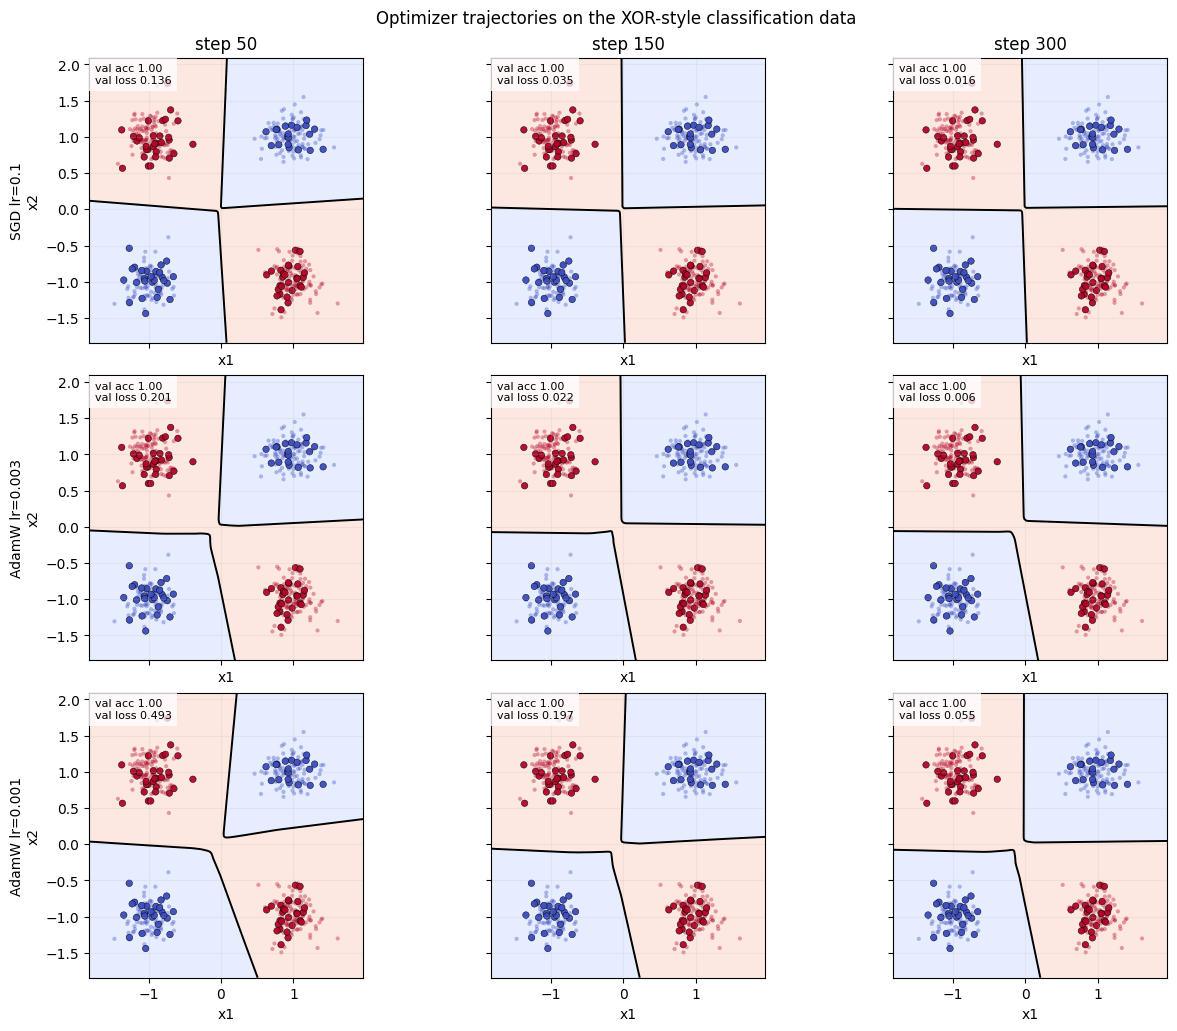

{'SGD lr=0.1': {50: {'train_loss': 0.1239,
   'val_loss': 0.1363,
   'val_accuracy': 1.0},
  150: {'train_loss': 0.0286, 'val_loss': 0.0354, 'val_accuracy': 1.0},
  300: {'train_loss': 0.0118, 'val_loss': 0.0157, 'val_accuracy': 1.0}},
 'AdamW lr=0.003': {50: {'train_loss': 0.187,
   'val_loss': 0.2007,
   'val_accuracy': 1.0},
  150: {'train_loss': 0.0182, 'val_loss': 0.0225, 'val_accuracy': 1.0},
  300: {'train_loss': 0.0048, 'val_loss': 0.0065, 'val_accuracy': 1.0}},
 'AdamW lr=0.001': {50: {'train_loss': 0.4863,
   'val_loss': 0.4928,
   'val_accuracy': 1.0},
  150: {'train_loss': 0.1829, 'val_loss': 0.1968, 'val_accuracy': 1.0},
  300: {'train_loss': 0.0475, 'val_loss': 0.0553, 'val_accuracy': 1.0}}}

In [10]:
optimizer_snapshot_summary = plot_optimizer_decision_snapshots(
    optimizer_runs,
    build_model=build_mlp,
    x_train=x_train,
    y_train=y_train,
    x_val=x_val,
    y_val=y_val,
    steps=(50, 150, 300),
    seed=0,
)

optimizer_snapshot_summary


In [11]:
'Question: Which optimizer was less sensitive to LR choice in this experiment?'
'Answer: '
'Question: Why does AdamW not change the model architecture or loss?'
'Answer: '

'Answer: '

## Exercise 5 - Gradient clipping

Clipping uses the global norm across parameters. It rescales the whole gradient vector; it does not clamp each tensor independently.

In [12]:
p1 = torch.zeros(1, requires_grad=True)
p2 = torch.zeros(1, requires_grad=True)
p1.grad = torch.tensor([3.0])
p2.grad = torch.tensor([4.0])

pre_clip_norm = clip_grad_norm_([p1, p2], max_norm=1.0)
print("pre-clip norm:", pre_clip_norm)
print("p1.grad:", p1.grad)
print("p2.grad:", p2.grad)
print("post-clip norm:", torch.sqrt((p1.grad ** 2).sum() + (p2.grad ** 2).sum()).item())

pre-clip norm: 5.0
p1.grad: tensor([0.6000])
p2.grad: tensor([0.8000])
post-clip norm: 0.9999998211860657


In [13]:
'Question: Why are both gradients multiplied by the same scale factor?'
'Answer: '
'Question: If clipping fires on nearly every step, what should you suspect?'
'Answer: '

'Answer: '

## Exercise 6 - Warmup and cosine decay

The schedule is pure arithmetic. Plotting it is the easiest way to internalize what `warmup_steps`, `max_steps`, `max_lr`, and `min_lr` mean.

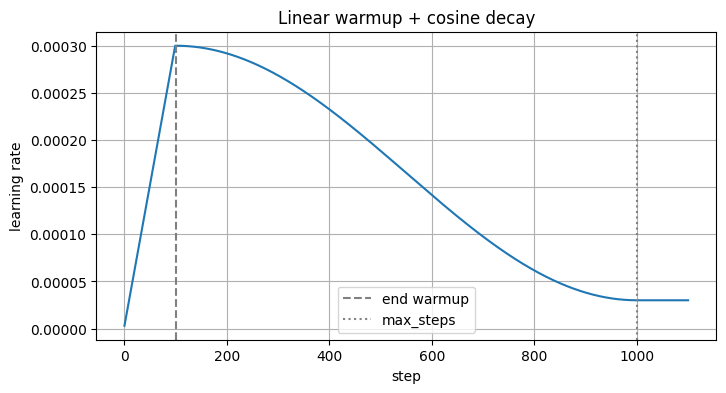

0 2.9999999999999997e-06
99 0.0003
100 0.0003
550 0.00016499999999999997
1000 3e-05
1100 3e-05


In [14]:
warmup_steps = 100
max_steps = 1000
max_lr = 3e-4
min_lr = 3e-5
steps = list(range(max_steps + 101))
lrs = [
    cosine_with_warmup(
        step,
        warmup_steps=warmup_steps,
        max_steps=max_steps,
        max_lr=max_lr,
        min_lr=min_lr,
    )
    for step in steps
]

plt.plot(steps, lrs)
plt.axvline(warmup_steps, color="gray", linestyle="--", label="end warmup")
plt.axvline(max_steps, color="gray", linestyle=":", label="max_steps")
plt.xlabel("step")
plt.ylabel("learning rate")
plt.title("Linear warmup + cosine decay")
plt.legend()
plt.show()

for step in [0, 99, 100, 550, 1000, 1100]:
    print(step, lrs[step])

In [ ]:
'Question: What happens at step 0, step 99, step 100, halfway through decay, and after max_steps?'
'Answer: '
'Question: Why might a transformer use warmup even when a small MLP does not need it?'
'Answer: '

In [ ]:
result = subprocess.run(
    [sys.executable, "-m", "pytest", "tests/test_training.py", "-q"],
    cwd=repo_root,
    text=True,
    capture_output=True,
)
print(result.stdout)
if result.stderr:
    print(result.stderr)
assert result.returncode == 0, "Training-dynamics tests are not passing yet."
print("Training-dynamics tests passed.")

## Exercise 7 - Curve diagnosis

For each case, write the most likely diagnosis and one next experiment. Keep the next experiment small: change one or two knobs, not everything.

In [ ]:
diagnosis_prompts = {
    "both high and flat": "train loss high, validation loss high, both barely move",
    "train low, val high": "train loss falls near zero, validation loss rises",
    "both decreasing": "train and validation loss both fall smoothly",
}

diagnoses = {
    "both high and flat": "",
    "train low, val high": "",
    "both decreasing": "",
}

diagnoses

When complete, ask a coding agent to grade your Module 03B notebook. Partial work is fine: the agent should grade answered questions and implemented sections, then skip blank prompts.